In [54]:
import torch
from torch import nn, Tensor
from torch.utils.data import DataLoader
import torchtext
from torchtext.data.metrics import bleu_score
import matplotlib.pyplot as plt
import string

import time
import math
import re

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [55]:
!pip show torch

Name: torch
Version: 2.3.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3
Location: /opt/anaconda3/envs/week4_ig/lib/python3.8/site-packages
Requires: filelock, fsspec, jinja2, networkx, sympy, typing-extensions
Required-by: pytorch-lightning, torchdata, torchmetrics, torchtext


In [56]:
import spacy

In [57]:
import random

In [58]:
from torchtext.datasets import Multi30k

In [59]:
spacy_en = spacy.load('en_core_web_md')
spacy_de = spacy.load('de_core_news_md')

In [60]:
sos_tok = '<sos>'
eos_tok = '<eos>'

def preprocessing_text(text):
    text = text.lower().strip()
    text = re.sub(f'[{string.punctuation}\n]', '', text)
    return text

def tokenize_de(text):
    text = [preprocessing_text(t) for t in text]
    return text

def tokenize_en(text):
    text = [preprocessing_text(t) for t in text]
    return text

In [61]:
from torchtext.data import Field

data_src = Field(tokenize=str.split,lower=True, init_token='<sos>', eos_token='<eos>')
data_trg = Field(tokenize=str.split,lower=True, init_token='<sos>', eos_token='<eos>')

In [62]:
train_data, valid_data, test_data = Multi30k.splits(
    exts=('.de', '.en'),
    fields=(data_src, data_trg),
    root='.data'  # download to .data
)

print(train_data[0].src)

class TextDatasets(torch.utils.data.Dataset):
    def __init__(self, raw_data):
        self.datasets = list(raw_data)
        
    def __len__(self):
        return len(self.datasets)
    
    def __getitem__(self, idx):
        x = self.datasets[idx]
        src = [sos_tok] + tokenize_de(x.src) + [eos_tok]
        trg = [sos_tok] + tokenize_en(x.trg) + [eos_tok]
        return src, trg

train_datasets = TextDatasets(train_data)
valid_datasets = TextDatasets(valid_data)
test_datasets = TextDatasets(test_data)
    
print("Train size:", len(train_datasets))
print("Valid size:", len(valid_datasets))
print("Test size:", len(test_datasets))

['zwei', 'junge', 'weiße', 'männer', 'sind', 'im', 'freien', 'in', 'der', 'nähe', 'vieler', 'büsche.']
Train size: 29000
Valid size: 1014
Test size: 1000


In [63]:
import pytorch_lightning as pl

class TextDatamodule(pl.LightningDataModule):
    def __init__(self, train, valid, test, batch_size=128):
        self.train = train
        self.test = test
        self.valid = valid
        self.batch_size = 128
        
    def train_dataloader(self):
        return DataLoader(self.train, self.batch_size)
    
    def val_dataloader(self):
        return DataLoader(self.valid, self.batch_size)
    
    def test_dataloader(self):
        return DataLoader(self.test, self.batch_size)
    
batch_size = 128    

dm = TextDatamodule(train_datasets,
                    valid_datasets,
                    test_datasets,
                    batch_size=batch_size)

In [64]:
train_data

In [65]:
type(train_data.src)

generator

In [66]:
%%time

src_corpus = []
trg_corpus = []
for src, trg in train_datasets:
    src_corpus.append(src)
    trg_corpus.append(trg)

CPU times: user 397 ms, sys: 6.56 ms, total: 403 ms
Wall time: 406 ms


In [67]:
from torchtext.vocab import build_vocab_from_iterator

In [68]:
src_vocab = build_vocab_from_iterator(src_corpus)
trg_vocab = build_vocab_from_iterator(trg_corpus)

# src_vocab.set_default_index(0)
# trg_vocab.set_default_index(0)

print("src vocab size:", len(src_vocab))
print("trg vocab size:", len(trg_vocab))

29000lines [00:00, 650735.43lines/s]
29000lines [00:00, 643257.34lines/s]

src vocab size: 18584
trg vocab size: 10206


In [69]:
import torchtext.data as data

In [70]:
data_src.build_vocab(train_data, min_freq=2)
data_trg.build_vocab(train_data, min_freq=2)

itos_src = data_src.vocab.itos
itos_trg = data_trg.vocab.itos

def get(itos, i):
    try:
        return itos[i]
    except:
        ...
    return '<unk>'

def decode_src(x: Tensor):
    return ' '.join([get(itos_src, i) for i in x])

def decode_trg(x: Tensor):
    return ' '.join([get(itos_trg, i) for i in x])

In [71]:
print(f"Unique tokens in source (de) vocabulary: {len(data_src.vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(data_trg.vocab)}")

Unique tokens in source (de) vocabulary: 9597
Unique tokens in target (en) vocabulary: 7704


In [72]:
from torchtext.data import BucketIterator

In [73]:
batch_size = 128

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data), 
    batch_size = batch_size, 
    device = device)

In [74]:
class Encoder(nn.Module):
    def __init__(self,
                input_dim: int,
                 
                emb_dim: int,
                hid_dim: int,
                n_layers: int,
                dropout: float = 0.1
                ):
        '''
            * Parameters:
                - input_dim: vocabulary_size
                - emb_dim: word embedding size
                - hid_dim: hidden states size
                - n_layers: number of RNN layers
                - dropout: dropout rate for rnn
        '''
        super().__init__()
        
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src: Tensor):
        '''
            * Input:
                - src: tensor of size (batch, src len)
            * Output:
                - h: hidden state vector
                - c: cell state vector
        '''
        embedded = self.dropout(self.embedding(src))
        out, (h, c) = self.rnn(embedded)
        return h, c
    
class Decoder(nn.Module):
    def __init__(self, 
                 output_dim: int,
                 emb_dim: int,
                 hid_dim: int,
                 n_layers: int,
                 dropout: float
                ):
        '''
            * Parameters:
                - input_dim: vocabulary_size
                - emb_dim: word embedding size
                - hid_dim: hidden states size
                - n_layers: number of RNN layers
                - dropout: dropout rate for rnn
        '''
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout, batch_first=True)
        self.fc1 = nn.Linear(hid_dim, 256)
        self.fc2= nn.Linear(256,128)
        self.fc3= nn.Linear(128,64)
        self.fc_out= nn.Linear(64,output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, trg, encoder_h, encoder_c):
        '''
            * Input:
                - trg: tensor of size (batch)
                - h: hidden state from encoder
                - c: cell state from encoder 
            * Output:
                - out: 
        '''
        trg = trg.unsqueeze(1) # [batch, 1]
        
        embedded = self.dropout(self.embedding(trg))
        
        out, (h, c) = self.rnn(embedded, (encoder_h, encoder_c))
        
        out = self.fc1(out.squeeze())
        out =self.fc2(out)
        out=self.fc3(out)
        out=self.fc_out(out)
        return out, h, c
    
class Seq2Seq(pl.LightningModule):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        
    def configure_optimizers(self):
        return torch.optim.Adam(model.parameters(), lr=0.001)
    
    def forward(self, src, trg, teacher_force_ratio = 0.0):
        teacher_force_ratio = 0.0
        h, c = self.encoder(src)
        
        decoder_input = trg[:, 0] # just get the <sos> token
        
        # [src len, batch size, vocab size]
        outputs = torch.zeros(trg.size(1), trg.size(0), self.decoder.fc_out.out_features)
        
        for t in range(1, trg.size(1)):
            out, h, c = self.decoder(decoder_input, h, c)
            
            outputs[t] = out
            
            top1 = out.argmax(1)
            
            use_teacher_force = random.random() < teacher_force_ratio
            
            decoder_input = trg[:, t] if use_teacher_force else top1
        
        return outputs
    
    def prediction(self, src, max_len=50):
        h, c = self.encoder(src)
        sos_id = data_trg.vocab.stoi[sos_tok]
        decoder_input = torch.tensor([[sos_id]])
        
    def training_step(self, batch, batch_idx):
        src, trg = batch
        outputs = self.forward(src, trg)
        
        output = output[1:].view(-1, output.size(-1))
        trg = trg[1:].view(-1)
        loss = criterion(output, trg)
        self.log('train_loss', loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        src, trg = batch
        outputs = self.forward(src, trg)
        
        output = output[1:].view(-1, output.size(-1))
        trg = trg[1:].view(-1)
        loss = criterion(output, trg)
        self.log('train_loss', loss)
        return loss
        
    def test_step(self, batch, batch_idx):
        src, trg = batch
        outputs = self.forward(src, trg)
    
        output = output[1:].view(-1, output.size(-1))
        trg = trg[1:].view(-1)
        loss = criterion(output, trg)
        self.log('train_loss', loss)
        return loss

In [75]:
input_dim = len(data_src.vocab)
output_dim = len(data_trg.vocab)
enc_emb_dim = 500
dec_emb_dim = 500
hid_dim = 512
n_layers = 3
enc_dropout = 0.5
dec_dropout = 0.5

encoder = Encoder(input_dim, enc_emb_dim, hid_dim, n_layers, enc_dropout).to(device)
decoder = Decoder(output_dim, dec_emb_dim, hid_dim, n_layers, dec_dropout).to(device)

model = Seq2Seq(encoder, decoder).to(device)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9597, 500)
    (rnn): LSTM(500, 512, num_layers=3, batch_first=True, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(7704, 500)
    (rnn): LSTM(500, 512, num_layers=3, batch_first=True, dropout=0.5)
    (fc1): Linear(in_features=512, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
    (fc3): Linear(in_features=128, out_features=64, bias=True)
    (fc_out): Linear(in_features=64, out_features=7704, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [76]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

trg_pad_idx = data_trg.vocab.stoi[data_trg.pad_token]

criterion = nn.CrossEntropyLoss(ignore_index=trg_pad_idx).to(device)

In [77]:
def train_epoch(model, iterator, optimizer, criterion):
    size = len(iterator.dataset)
    model.train()
    
    total_loss = 0
    start_time = time.perf_counter()
    for i, batch in enumerate(iterator):
        src = batch.src.permute(1, 0) # swap -> (batch, src len)
        trg = batch.trg.permute(1, 0) # swap -> (batch, trg len)
        
        optimizer.zero_grad()

        output = model(src, trg).to(device) # [trg len, batch, vocab size]
        
        # get from 1 -> remove sos token
        output = output[1:].view(-1, output.size(-1))
        trg = trg[:, 1:].contiguous().view(-1)
            
        loss = criterion(output, trg)
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item()
    
        if i % 100 == 0:
            loss, current = loss.item(), i * len(src)
            print(f"Loss: {loss:>7f} [{current:>5d}/{size:>5d} ({round(current/size * 100)}%)] [{round(time.perf_counter() - start_time, 2):>6}s]")
    
    return total_loss / len(iterator)

def eval_epoch(model, iterator, criterion):
    size = len(iterator.dataset)
    model.eval()
    
    start_time = time.perf_counter()
    with torch.no_grad():
        total_loss = 0
        for i, batch in enumerate(iterator):
            src = batch.src.permute(1, 0) # swap (batch, len)
            trg = batch.trg.permute(1, 0)

            output = model(src, trg).to(device)
            
            output = output[1:].view(-1, output.size(-1))
            trg = trg[:, 1:].contiguous().view(-1)
            
            loss = criterion(output, trg)

            total_loss += loss.item()

            if i % 100 == 0:
                loss, current = loss.item(), i * len(src)
                print(f"Loss: {loss:>7f} [{current:>5d}/{size:>5d} ({round(current/size * 100)}%)] [{round(time.perf_counter() - start_time, 2):>6}s]")
    
    
    return total_loss / len(iterator)

In [78]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [79]:
n_epochs = 1

best_valid_loss = float('inf')

list_train_loss = []
list_valid_loss = []

for epoch in range(n_epochs):
    
    start_time = time.time()
    
    train_loss = train_epoch(model, train_iterator, optimizer, criterion)
    valid_loss = eval_epoch(model, valid_iterator, criterion)
    
    list_train_loss.append(train_loss)
    list_valid_loss.append(valid_loss)
    
    end_time = time.time()
    
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'nmt-model.pt')
    
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

Loss: 8.949715 [    0/29000 (0%)] [  0.96s]
Loss: 5.576526 [12800/29000 (44%)] [ 90.79s]
Loss: 5.593176 [25600/29000 (88%)] [177.16s]
Loss: 5.447978 [    0/ 1014 (0%)] [  0.11s]
Epoch: 01 | Time: 3m 20s
	Train Loss: 5.860 | Train PPL: 350.730
	 Val. Loss: 5.530 |  Val. PPL: 252.162


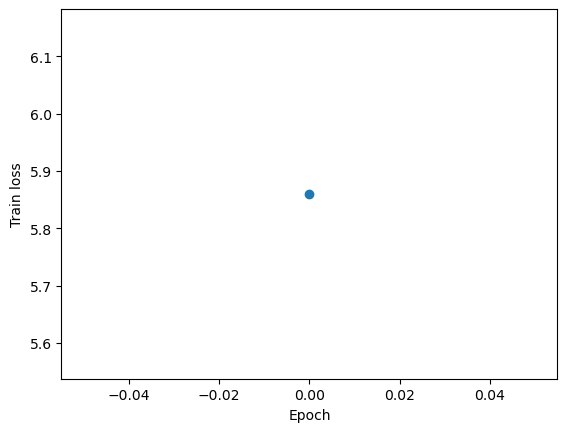

In [80]:
x = torch.arange(len(list_train_loss))
plt.plot(x, list_train_loss)
plt.scatter(x, list_train_loss)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.show()

In [81]:
model.load_state_dict(torch.load('nmt-model.pt'))

test_loss = eval_epoch(model, test_iterator, criterion)

print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')

Loss: 5.538337 [    0/ 1000 (0%)] [   0.1s]
| Test Loss: 5.559 | Test PPL: 259.508 |


In [82]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adityaamehra/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [83]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu
from nltk.tokenize import word_tokenize

# Sample reference and candidate
reference = ["this is a small test".split()]
candidate = "this is a test".split()

# Compute sentence-level BLEU score (unigram and bigram)
score = sentence_bleu(reference, candidate, weights=(0.5, 0.5))
print(f"Sentence BLEU score: {score:.4f}")

# For multiple sentences — corpus-level BLEU
references = [[word_tokenize("this is a small test")], [word_tokenize("hello how are you")]]
candidates = [word_tokenize("this is a test"), word_tokenize("hello how you")]

corpus_score = corpus_bleu(references, candidates)
print(f"Corpus BLEU score: {corpus_score:.4f}")


Sentence BLEU score: 0.6359
Corpus BLEU score: 0.0000


/opt/anaconda3/envs/week4_ig/lib/python3.8/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


In [84]:
def translate_sentence(model, sentence, src_vocab, trg_vocab, tokenize_fn, sos_tok="<sos>", eos_tok="<eos>", max_len=10, device='cuda'):
    model.eval()
    
    # Tokenize and convert to indices
    tokens = [sos_tok] + tokenize_fn(sentence) + [eos_tok]
    src_indices = [src_vocab.stoi.get(token, src_vocab.stoi["<unk>"]) for token in tokens]
    src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(device)  # [1, src_len]
    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)  # returns (h, c)
    
    trg_indices = [trg_vocab.stoi[sos_tok]]
    print(f"Source indices: {src_indices}")
    print(f"Target indices: {trg_indices}")
    for _ in range(max_len):
        trg_tensor = torch.tensor([trg_indices[-1]], dtype=torch.long).to(device)  # [1]
        print(f"Current target tensor: {trg_tensor}")
        with torch.no_grad():
            output, hidden, cell = model.decoder(trg_tensor, hidden, cell)  # output: [1, vocab_size]
            print(f"Decoder output: {output}")
        output = output.unsqueeze(0)  # [1, 1, vocab_size]
        print(f"Output after unsqueeze: {output.shape}")
        pred_token = output.argmax(1).item()
        print(f"Predicted token: {pred_token}")
        trg_indices.append(pred_token)
        
        if pred_token == trg_vocab.stoi[eos_tok]:
            break

    trg_tokens = [trg_vocab.itos[i] for i in trg_indices[1:-1]]  # Remove <sos> and <eos>
    
    return ' '.join(trg_tokens)
src_sentence = "das ist ein test".split()
translation = translate_sentence(model, src_sentence, data_src.vocab, data_trg.vocab, tokenize_de, device=device)
print(f"Source: {src_sentence}")
print(f"Translation: {translation}")

Source indices: [2, 34, 67, 4, 0, 3]
Target indices: [2]
Current target tensor: tensor([2])
Decoder output: tensor([ 4.6355, -4.6725, -5.9677,  ..., -3.0812, -3.4243, -3.2927])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6253, -4.6567, -5.9577,  ..., -3.0737, -3.4211, -3.2838])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6252, -4.6577, -5.9586,  ..., -3.0744, -3.4214, -3.2847])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6243, -4.6577, -5.9577,  ..., -3.0739, -3.4209, -3.2842])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6228, -4.6570, -5.9563,  ..., -3.0730, -3.4201, -3.2833])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target ten

In [85]:
data_trg.vocab.itos[4]


'a'

In [86]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.tokenize import word_tokenize

sentence_scores = []

for example in test_data.examples:
    # Original source and target
    src_sentence = ' '.join(example.src)
    trg_sentence = ' '.join(example.trg)
    src_sentence=src_sentence.split()
    trg_sentence=trg_sentence.split()
    # Model translation
    pred_sentence = translate_sentence(
        model, 
        src_sentence, 
        data_src.vocab, 
        data_trg.vocab, 
        tokenize_fn=tokenize_de, 
        device=device
    )
    print(f"Predicted: {pred_sentence}")
    # Tokenize reference and hypothesis
    reference = trg_sentence  # wrapped in list
    candidate = pred_sentence

    # Compute sentence BLEU score (default is up to 4-gram)
    score = sentence_bleu(reference, candidate)
    sentence_scores.append(score)

    print(f"Source: {src_sentence}")
    print(f"Target: {trg_sentence}")
    print(f"Predicted: {pred_sentence}")
    print(f"BLEU Score: {score:.4f}\n")


Source indices: [2, 4, 11, 9, 5, 150, 102, 13, 80, 0, 3]
Target indices: [2]
Current target tensor: tensor([2])
Decoder output: tensor([ 4.6380, -4.6762, -5.9725,  ..., -3.0831, -3.4275, -3.2947])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6265, -4.6579, -5.9599,  ..., -3.0738, -3.4219, -3.2841])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6274, -4.6592, -5.9617,  ..., -3.0751, -3.4229, -3.2851])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6270, -4.6591, -5.9608,  ..., -3.0754, -3.4226, -3.2851])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6264, -4.6584, -5.9602,  ..., -3.0753, -3.4224, -3.2849])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 

/opt/anaconda3/envs/week4_ig/lib/python3.8/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/opt/anaconda3/envs/week4_ig/lib/python3.8/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


Decoder output: tensor([ 4.6275, -4.6593, -5.9618,  ..., -3.0750, -3.4229, -3.2852])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6271, -4.6593, -5.9608,  ..., -3.0755, -3.4226, -3.2852])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6265, -4.6585, -5.9603,  ..., -3.0754, -3.4224, -3.2850])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6261, -4.6580, -5.9599,  ..., -3.0752, -3.4222, -3.2848])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6259, -4.6579, -5.9598,  ..., -3.0752, -3.4221, -3.2847])
Output after unsqueeze: torch.Size([1, 7704])
Predicted token: 4
Current target tensor: tensor([4])
Decoder output: tensor([ 4.6257, -4.6578, -5.9595,  ..., -3.0751, -3.4219, 